In [2]:
import cv2, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.svm import SVC, LinearSVC
import shap


/Users/i-kondo/program/kadai/animal-face-classifier/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [43]:
CAT_SIZE = 4000
DOG_SIZE = 4000
HUMAN_SIZE = 200
IMAGE_SHAPE = (128, 128)

In [11]:
from rembg import remove
from PIL import Image
import cv2, numpy as np, os
from pathlib import Path

def load_and_preprocess(
        image_paths,
        size=(128, 128),
        use_rembg=True,
        cache_dir: str | None = None   # 透過PNGを再利用したい場合
    ):
    images = []
    for p in map(Path, image_paths):
        if not p.exists():
            print("読み込み失敗:", p)
            continue

        # ---------- 背景除去 ----------
        if use_rembg:
            # ① 既にキャッシュがあれば再利用
            if cache_dir:
                cache_dir = Path(cache_dir); cache_dir.mkdir(exist_ok=True, parents=True)
                cache_path = cache_dir / (p.stem + "_fg.png")
                if cache_path.exists():
                    bgr = cv2.imread(str(cache_path))
                else:
                    bgr = _remove_bg_and_save(p, cache_path)
            else:
                bgr = _remove_bg_and_save(p)          # キャッシュ無し
        else:
            bgr = cv2.imread(str(p))                  # 背景付きのまま

        if bgr is None:
            print("読み込み失敗:", p)
            continue

        # ---------- グレースケール + 前処理 ----------
        gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
        gray = cv2.resize(gray, size)
        gray = cv2.equalizeHist(gray)
        images.append(gray.flatten().astype(np.float32))

    return np.array(images)

# ────────────────────────────────
def _remove_bg_and_save(src_path: Path, dst_path: Path | None = None):
    """
    1枚だけ背景を抜いてBGR(白埋め)を返す。
    dst_path を渡すと透過PNGを保存してキャッシュ化。
    """
    # OpenCV -> RGBA (Pillow は RGBA 想定)
    bgr  = cv2.imread(str(src_path))
    rgba = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGBA)
    fg_rgba = np.array(remove(Image.fromarray(rgba)))   # rembg 推論

    # 透過部 (α=0) を白 255 で埋める
    alpha = fg_rgba[:, :, 3]
    bgr   = fg_rgba[:, :, :3]
    bgr[alpha == 0] = 255

    # キャッシュ保存（任意）
    if dst_path is not None:
        cv2.imwrite(str(dst_path), bgr)

    return bgr


In [12]:
cat_paths   = [f"images/cats/{i}.jpg"   for i in range(CAT_SIZE)]
dog_paths   = [f"images/dogs/{i}.jpg"   for i in range(DOG_SIZE)]
human_paths = [f"images/humans/{i}.jpg" for i in range(HUMAN_SIZE)]

cat_images   = load_and_preprocess(cat_paths,   cache_dir="cache/cats_fg")
dog_images   = load_and_preprocess(dog_paths,   cache_dir="cache/dogs_fg")
human_images = load_and_preprocess(human_paths, cache_dir="cache/humans_fg")

# 念のためエラー確認
print("NaN含むか:", np.isnan(cat_images).any(), np.isnan(dog_images).any(), np.isnan(human_images).any())
print("inf含むか:", np.isinf(cat_images).any(), np.isinf(dog_images).any(), np.isinf(human_images).any())


100%|████████████████████████████████████████| 176M/176M [00:00<00:00, 178GB/s]


NaN含むか: False False False
inf含むか: False False False


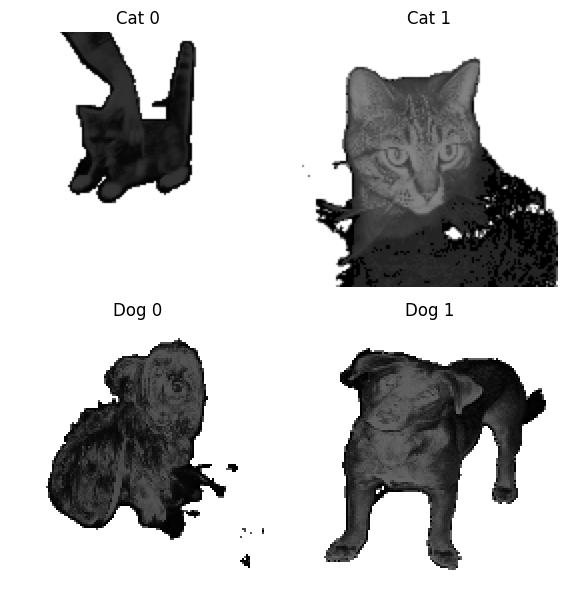

In [39]:
# 猫と犬の画像を2枚ずつ表示
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
for i in range(2):
    axes[0, i].imshow(cat_images[i].reshape(IMAGE_SHAPE), cmap='gray')
    axes[0, i].set_title(f"Cat {i}")
    axes[0, i].axis('off')
    axes[1, i].imshow(dog_images[i].reshape(IMAGE_SHAPE), cmap='gray')
    axes[1, i].set_title(f"Dog {i}")
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

In [51]:
idx = np.random.choice(len(cat_images), CAT_SIZE, replace=True)
sampled_cat_images = cat_images[idx]

idx = np.random.choice(len(dog_images), DOG_SIZE, replace=True)
sampled_dog_images = dog_images[idx]

In [52]:
X = np.vstack([sampled_cat_images, sampled_dog_images])
y = np.array([0]*CAT_SIZE + [1]*DOG_SIZE)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("訓練データ数:", X_train.shape[0], "テストデータ数:", X_test.shape[0])
pca = PCA(n_components=0.80, whiten=True, random_state=42)  # 主成分数を自動決定 (累積寄与率85%)
X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)
print("残った次元数:", pca.n_components_)
print("PCA後の次元数:", X_train_pca.shape[1])
print("訓練データ数:", X_train_pca.shape[0], "テストデータ数:", X_test_pca.shape[0])


訓練データ数: 6400 テストデータ数: 1600
残った次元数: 110
PCA後の次元数: 110
訓練データ数: 6400 テストデータ数: 1600


/Users/i-kondo/program/kadai/animal-face-classifier/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/i-kondo/program/kadai/animal-face-classifier/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/i-kondo/program/kadai/animal-face-classifier/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/i-kondo/program/kadai/animal-face-classifier/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:155: RuntimeWarning: divide by zero encountered in matmul
  X_transformed -= xp.reshape(self.mean_, (1, -1)) @ self.components_.T
/Users/i-kondo/program/kadai/animal-face-classifier/.venv/lib/python3.13/site-packages/sklearn/decomposition

In [53]:
print("訓練データ内の猫の数:", np.sum(y_train == 0))
print("訓練データ内の犬の数:", np.sum(y_train == 1))
print("テストデータ内の猫の数:", np.sum(y_test == 0))
print("テストデータ内の犬の数:", np.sum(y_test == 1))

訓練データ内の猫の数: 3196
訓練データ内の犬の数: 3204
テストデータ内の猫の数: 804
テストデータ内の犬の数: 796


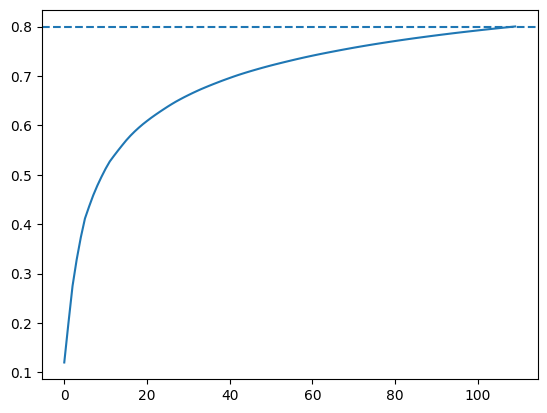

In [54]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.axhline(0.80, linestyle='--')

In [55]:
param_grid = {
    'C':     [0.1, 1, 10],       # 正則化パラメータ
    'gamma': [0.001, 0.01, 0.1, 1]  # RBF カーネル幅の自動計算方式
}

clf = GridSearchCV(SVC(kernel='rbf', probability=True), param_grid, cv=5)
clf.fit(X_train_pca, y_train)
print("Best params:", clf.best_params_)
print("Test acc:", clf.score(X_test_pca, y_test))


Best params: {'C': 10, 'gamma': 0.01}
Test acc: 0.89875


In [56]:
# 人間画像をPCA変換し、モデルで予測
human_images_pca = pca.transform(human_images)
human_pred = clf.predict(human_images_pca)
human_pred_proba = clf.predict_proba(human_images_pca)

print("人間画像の予測ラベル分布:", np.bincount(human_pred))
print("最初の10枚の予測ラベル:", human_pred[:10])
print("最初の10枚の予測確率:", human_pred_proba[:10])

人間画像の予測ラベル分布: [ 56 144]
最初の10枚の予測ラベル: [1 0 0 1 1 1 1 1 0 1]
最初の10枚の予測確率: [[0.21543295 0.78456705]
 [0.60256334 0.39743666]
 [0.93294629 0.06705371]
 [0.12156658 0.87843342]
 [0.07557095 0.92442905]
 [0.2462328  0.7537672 ]
 [0.10187358 0.89812642]
 [0.34489745 0.65510255]
 [0.76094831 0.23905169]
 [0.23601678 0.76398322]]


/Users/i-kondo/program/kadai/animal-face-classifier/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/i-kondo/program/kadai/animal-face-classifier/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/i-kondo/program/kadai/animal-face-classifier/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/i-kondo/program/kadai/animal-face-classifier/.venv/lib/python3.13/site-packages/sklearn/decomposition/_base.py:155: RuntimeWarning: divide by zero encountered in matmul
  X_transformed -= xp.reshape(self.mean_, (1, -1)) @ self.components_.T
/Users/i-kondo/program/kadai/animal-face-classifier/.venv/lib/python3.13/site-packages/sklearn/decomposition

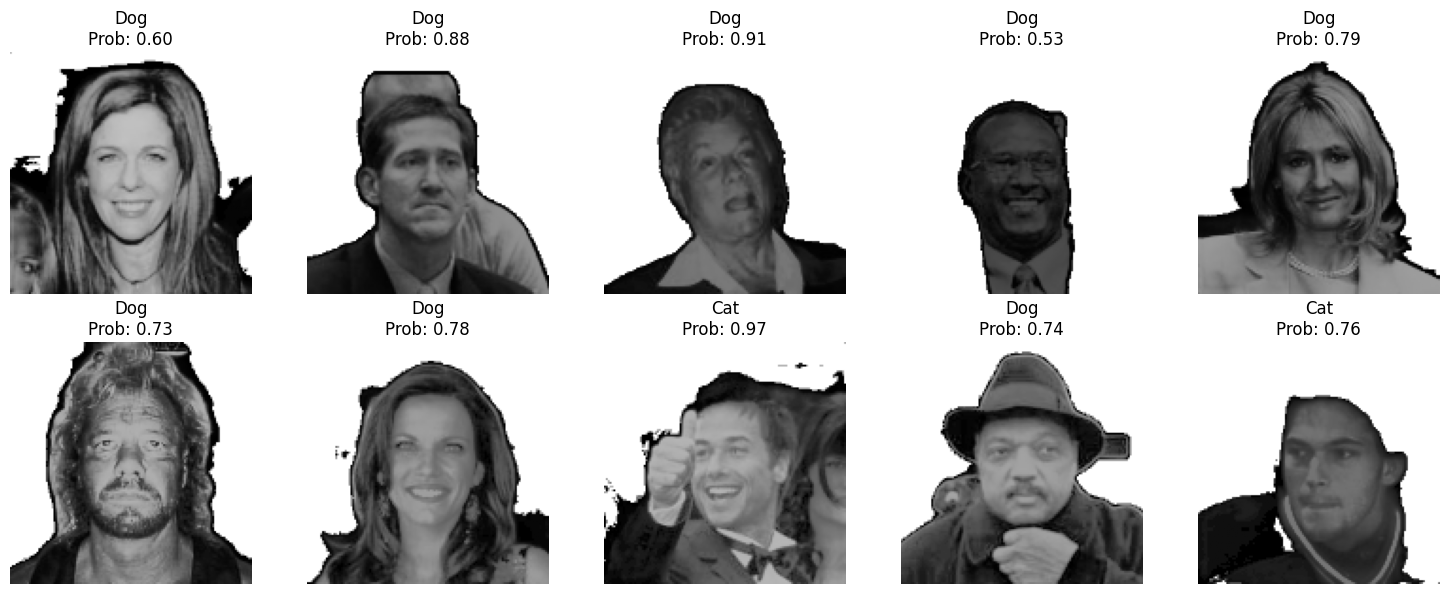

In [57]:
# ランダムに10枚選んで画像と予測ラベル・確率を表示
n_samples = 10
rand_idx = np.random.choice(len(human_images), n_samples, replace=False)
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, idx in zip(axes.flatten(), rand_idx):
    img = human_images[idx].reshape(IMAGE_SHAPE)
    pred = human_pred[idx]
    proba = human_pred_proba[idx][pred]
    label = "Dog" if pred == 1 else "Cat"
    ax.imshow(img, cmap='gray')
    ax.set_title(f"{label}\nProb: {proba:.2f}")
    ax.axis('off')
plt.tight_layout()
plt.show()